# Blinkit Data Analytics — Product, category and margin
DuckDB SQL + Python | Yash Prajapati

## 1. Setup

### 1.1 Libraries

In [1]:
import warnings, math, textwrap
warnings.filterwarnings('ignore')
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams.update({'figure.figsize':(10,4.5),'axes.grid':True,'grid.alpha':.25,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

duckdb 1.5.5 | pandas 3.0.2 | numpy 2.4.4


### 1.2 Load cleaned workbook

In [2]:
XLSX = 'data/Blinkit_analysis_new.xlsx'
book = pd.read_excel(XLSX, sheet_name=None)
geo = pd.read_csv('data/city_state_zone.csv')
for name, df in book.items():
    print(f'{name:28s} {df.shape[0]:>6,} rows  {df.shape[1]:>3} cols')

Data_Quality_Report              46 rows    3 cols
Orders_Customer_Info          5,000 rows   16 cols
Orders_Raw_Archive            5,000 rows   23 cols
Order_Line_Items              5,000 rows   14 cols
Delivery_Performance          5,000 rows    8 cols
Customer_Feedback             5,000 rows    8 cols
Customers                     2,500 rows   11 cols
Products                        268 rows   10 cols
Inventory_Analysis              268 rows   18 cols
Data_Dictionary                  44 rows    4 cols
Reference_Parameters             11 rows    5 cols
Relational_Diagram                0 rows    0 cols
Pivot_Payment_Method              7 rows    7 cols
Pivot_Customer_Segment            7 rows    5 cols
Pivot_Category_Sales             14 rows    4 cols
Pivot_Monthly_Trend              24 rows    6 cols
Pivot_Area_Delivery              23 rows    6 cols
Pivot_Inventory_Movement          6 rows    7 cols
Pivot_Category_Stock             14 rows    8 cols


### 1.3 Create DuckDB database and load tables

In [3]:
con = duckdb.connect('blinkit.duckdb')
load = {'orders_src':'Orders_Raw_Archive','items_src':'Order_Line_Items','delivery_src':'Delivery_Performance',
        'feedback_src':'Customer_Feedback','customers_src':'Customers','products_src':'Products','inventory_src':'Inventory_Analysis'}
for tbl, sheet in load.items():
    df = book[sheet].copy()
    df.columns = [c.strip() for c in df.columns]
    con.register('tmp_df', df)
    con.execute(f'CREATE OR REPLACE TABLE {tbl} AS SELECT * FROM tmp_df')
con.register('geo_df', geo)
con.execute('CREATE OR REPLACE TABLE geo AS SELECT * FROM geo_df')
con.execute("SELECT table_name, estimated_size FROM duckdb_tables() ORDER BY table_name").df()

,table_name,estimated_size
0,customers_src,2500
1,delivery_src,5000
2,feedback_src,5000
3,geo,316
4,inventory_src,268
5,items_src,5000
6,orders_src,5000
7,products_src,268


### 1.4 Typed analysis views

In [4]:
con.execute('''
CREATE OR REPLACE VIEW orders AS
SELECT order_id, customer_id,
       strptime(order_date, '%d-%m-%Y %H:%M')              AS order_ts,
       CAST(strptime(order_date, '%d-%m-%Y %H:%M') AS DATE) AS order_date,
       strptime(promised_delivery_time, '%d-%m-%Y %H:%M')   AS promised_ts,
       strptime(actual_delivery_time,  '%d-%m-%Y %H:%M')    AS actual_ts,
       delivery_status, order_total, payment_method, delivery_partner_id, store_id,
       CAST(delivery_time_minutes AS INTEGER)               AS delay_min,
       distance_km, reasons_if_delayed, customer_name,
       trim(area) AS area, pincode, customer_segment,
       CAST(registration_date AS DATE)                      AS registration_date,
       order_day_of_week, order_time_slot, order_value_segment,
       CASE WHEN is_weekend = 'Yes' THEN 1 ELSE 0 END       AS is_weekend
FROM orders_src ''')

con.execute('''
CREATE OR REPLACE VIEW items AS
SELECT order_id, product_id, quantity, unit_price, product_name, category, brand,
       price, mrp, margin_percentage, shelf_life_days, min_stock_level, max_stock_level, line_total,
       line_total * margin_percentage / 100.0 AS margin_value
FROM items_src ''')

con.execute('''
CREATE OR REPLACE VIEW feedback AS
SELECT feedback_id, order_id, customer_id, rating, feedback_category, sentiment,
       CAST(feedback_date AS DATE) AS feedback_date
FROM feedback_src ''')

con.execute('''
CREATE OR REPLACE VIEW f_sales AS
SELECT o.order_id, o.customer_id, o.order_ts, o.order_date,
       date_trunc('month', o.order_date)  AS order_month,
       extract(hour FROM o.order_ts)      AS order_hour,
       o.order_day_of_week, o.is_weekend, o.order_time_slot, o.order_value_segment,
       o.payment_method, o.customer_segment, o.registration_date, o.customer_name,
       o.area, g.state, g.zone, g.city_tier,
       i.product_id, i.product_name, i.category, i.brand,
       i.quantity, i.line_total AS revenue, i.margin_value, i.margin_percentage,
       i.price, i.mrp, i.shelf_life_days,
       o.delay_min, o.distance_km, o.delivery_status,
       CASE WHEN o.delivery_status = 'On Time' THEN 1 ELSE 0 END AS is_on_time_status,
       CASE WHEN o.delay_min > 0 THEN 1 ELSE 0 END               AS is_late_minutes,
       f.rating, f.sentiment, f.feedback_category
FROM orders o
JOIN items i    ON i.order_id = o.order_id
LEFT JOIN geo g ON g.area     = o.area
LEFT JOIN feedback f ON f.order_id = o.order_id ''')

con.execute('SELECT COUNT(*) AS fact_rows, COUNT(DISTINCT order_id) AS orders, MIN(order_date) AS first_day, MAX(order_date) AS last_day FROM f_sales').df()

,fact_rows,orders,first_day,last_day
0,5000,5000,2023-03-16,2024-11-04


### 1.5 Query helper

In [5]:
def q(sql, con=con):
    return con.execute(textwrap.dedent(sql)).df()

def pct(x, n):
    return round(100.0 * x / n, 2) if n else 0.0

q('SELECT COUNT(*) AS rows_in_fact_view FROM f_sales')

,rows_in_fact_view
0,5000


### Chart colours

In [6]:
GREEN, GOLD, BLUE, RED, GREY = '#0B7A2A', '#E0A31C', '#2A6FD0', '#CC3B37', '#8A938D'

## 6. Product, category and margin

### 6.1 Category rank by revenue against rank by margin

In [7]:
q('''
WITH c AS (
  SELECT category, SUM(revenue) AS revenue, SUM(margin_value) AS margin_value,
         AVG(margin_percentage) AS margin_pct FROM f_sales GROUP BY 1)
SELECT category, round(revenue, 0) AS revenue, round(margin_pct, 1) AS margin_pct,
       round(margin_value, 0) AS margin_value,
       RANK() OVER (ORDER BY revenue DESC)      AS revenue_rank,
       RANK() OVER (ORDER BY margin_value DESC) AS margin_rank,
       RANK() OVER (ORDER BY revenue DESC) - RANK() OVER (ORDER BY margin_value DESC) AS rank_shift,
       round(100 * margin_value / SUM(margin_value) OVER (), 2) AS margin_share_pct
FROM c ORDER BY margin_value DESC ''')

,category,revenue,margin_pct,margin_value,revenue_rank,margin_rank,rank_shift,margin_share_pct
0,Pet Care,"539,889.00",35.00,"188,961.00",4,1,3,13.88
1,Fruits & Vegetables,"559,053.00",25.00,"139,763.00",3,2,1,10.26
2,Personal Care,"394,895.00",35.00,"138,213.00",6,3,3,10.15
3,Snacks & Munchies,"394,649.00",35.00,"138,127.00",7,4,3,10.14
4,Dairy & Breakfast,"639,222.00",20.00,"127,844.00",1,5,-4,9.39
5,Instant & Frozen Food,"307,213.00",40.00,"122,885.00",11,6,5,9.03
6,Pharmacy,"592,369.00",20.00,"118,474.00",2,7,-5,8.70
7,Cold Drinks & Juices,"392,718.00",30.00,"117,815.00",8,8,0,8.65
8,Household Care,"444,244.00",25.00,"111,061.00",5,9,-4,8.16
9,Baby Care,"348,227.00",30.00,"104,468.00",10,10,0,7.67


### 6.2 Top 3 products inside each category

In [8]:
q('''
WITH p AS (
  SELECT category, product_name, SUM(revenue) AS revenue, SUM(quantity) AS units
  FROM f_sales GROUP BY 1, 2),
r AS (SELECT *, ROW_NUMBER() OVER (PARTITION BY category ORDER BY revenue DESC) AS rn,
             100 * revenue / SUM(revenue) OVER (PARTITION BY category) AS share_in_category
      FROM p)
SELECT category, rn AS rank_in_category, product_name, round(revenue, 0) AS revenue,
       units, round(share_in_category, 1) AS share_in_category_pct
FROM r WHERE rn <= 3 ORDER BY category, rn ''')

,category,rank_in_category,product_name,revenue,units,share_in_category_pct
0,Baby Care,1,Baby Wipes,"158,768.00",328.00,45.60
1,Baby Care,2,Baby Food,"137,443.00",236.00,39.50
2,Baby Care,3,Diapers,"52,016.00",91.00,14.90
3,Cold Drinks & Juices,1,Cola,"132,367.00",230.00,33.70
4,Cold Drinks & Juices,2,Orange Juice,"106,444.00",222.00,27.10
5,Cold Drinks & Juices,3,Iced Tea,"71,171.00",118.00,18.10
6,Dairy & Breakfast,1,Bread,"184,851.00",270.00,28.90
7,Dairy & Breakfast,2,Eggs,"137,397.00",246.00,21.50
8,Dairy & Breakfast,3,Butter,"106,843.00",148.00,16.70
9,Fruits & Vegetables,1,Onions,"138,858.00",222.00,24.80


### 6.3 Product codes per product name

In [9]:
q('''
SELECT product_name, any_value(category) AS category,
       COUNT(DISTINCT product_id) AS product_codes,
       COUNT(DISTINCT order_id)   AS orders,
       round(SUM(revenue), 0)     AS revenue,
       round(SUM(revenue) / COUNT(DISTINCT product_id), 0) AS revenue_per_code
FROM f_sales GROUP BY product_name HAVING COUNT(DISTINCT product_id) > 1
ORDER BY product_codes DESC, revenue DESC LIMIT 15 ''')

,product_name,category,product_codes,orders,revenue,revenue_per_code
0,Pet Treats,Pet Care,12,233,"252,007.00","21,001.00"
1,Vitamins,Pharmacy,10,183,"260,822.00","26,082.00"
2,Toilet Cleaner,Household Care,10,205,"199,837.00","19,984.00"
3,Dish Soap,Household Care,10,184,"184,441.00","18,444.00"
4,Lotion,Personal Care,10,188,"136,400.00","13,640.00"
5,Cough Syrup,Pharmacy,9,190,"203,570.00","22,619.00"
6,Baby Wipes,Baby Care,8,176,"158,768.00","19,846.00"
7,Pulses,Grocery & Staples,8,137,"94,641.00","11,830.00"
8,Bread,Dairy & Breakfast,7,135,"184,851.00","26,407.00"
9,Cat Food,Pet Care,7,152,"166,596.00","23,799.00"


### 6.4 ABC classification of product codes

In [10]:
abc = q('''
WITH p AS (SELECT product_id, any_value(product_name) AS product_name, any_value(category) AS category,
                  SUM(revenue) AS revenue, SUM(quantity) AS units FROM f_sales GROUP BY product_id),
r AS (SELECT *, 100 * SUM(revenue) OVER (ORDER BY revenue DESC ROWS UNBOUNDED PRECEDING) / SUM(revenue) OVER () AS cum_pct
      FROM p)
SELECT *, CASE WHEN cum_pct <= 80 THEN 'A' WHEN cum_pct <= 95 THEN 'B' ELSE 'C' END AS abc_class FROM r ''')
abc.groupby('abc_class').agg(products=('product_id','count'), revenue=('revenue','sum'),
                             units=('units','sum')).assign(
    revenue_share_pct=lambda d: (100*d.revenue/d.revenue.sum()).round(2),
    product_share_pct=lambda d: (100*d.products/d.products.sum()).round(2)).reset_index()

,abc_class,products,revenue,units,revenue_share_pct,product_share_pct
0,A,138,"3,974,367.98","5,499.00",79.93,51.49
1,B,67,"742,673.10","2,339.00",14.94,25.00
2,C,63,"255,374.35","2,196.00",5.14,23.51


### 6.5 XYZ classification on demand variability

In [11]:
monthly = q('''
SELECT product_id, order_month, SUM(quantity) AS units FROM f_sales GROUP BY 1, 2 ''')
piv = monthly.pivot_table(index='product_id', columns='order_month', values='units', aggfunc='sum').fillna(0)
cv = (piv.std(axis=1) / piv.mean(axis=1).replace(0, np.nan)).rename('cv')
xyz = cv.to_frame().assign(xyz_class=lambda d: pd.cut(d.cv, [-0.01, 0.5, 1.0, np.inf], labels=['X','Y','Z']))
abc_xyz = abc.set_index('product_id')[['product_name','category','revenue','abc_class']].join(xyz)
matrix = pd.crosstab(abc_xyz.abc_class, abc_xyz.xyz_class)
matrix.loc['Total'] = matrix.sum(); matrix['Total'] = matrix.sum(axis=1)
matrix

xyz_class,Y,Z,Total
abc_class,,,
A,40,98,138
B,8,59,67
C,14,49,63
Total,62,206,268


### 6.6 Revenue and risk profile of each ABC-XYZ group

In [12]:
abc_xyz.assign(group=abc_xyz.abc_class.astype(str) + abc_xyz.xyz_class.astype(str)) \
    .groupby('group').agg(products=('revenue','size'), revenue=('revenue','sum'), avg_cv=('cv','mean')) \
    .assign(revenue_share_pct=lambda d: (100*d.revenue/d.revenue.sum()).round(2),
            avg_cv=lambda d: d.avg_cv.round(2)).sort_values('revenue', ascending=False).reset_index()

,group,products,revenue,avg_cv,revenue_share_pct
0,AZ,98,"2,724,770.71",1.23,54.80
1,AY,40,"1,249,597.27",0.91,25.13
2,BZ,59,"642,590.96",1.27,12.92
3,CZ,49,"200,438.19",1.23,4.03
4,BY,8,"100,082.14",0.93,2.01
5,CY,14,"54,936.16",0.94,1.10


### 6.7 Price band performance

In [13]:
q('''
SELECT CASE WHEN price < 50 THEN 'a. under 50' WHEN price < 100 THEN 'b. 50-100'
            WHEN price < 250 THEN 'c. 100-250' WHEN price < 500 THEN 'd. 250-500'
            ELSE 'e. 500 and above' END AS price_band,
       COUNT(DISTINCT product_id) AS product_codes, SUM(quantity) AS units,
       round(SUM(revenue), 0) AS revenue, round(AVG(price), 0) AS avg_price,
       round(100 * SUM(revenue) / SUM(SUM(revenue)) OVER (), 2) AS revenue_share_pct
FROM f_sales GROUP BY 1 ORDER BY 1 ''')

,price_band,product_codes,units,revenue,avg_price,revenue_share_pct
0,a. under 50,14,500.00,"16,986.00",34.00,0.34
1,b. 50-100,16,598.00,"49,686.00",83.00,1.00
2,c. 100-250,44,"1,631.00","291,163.00",178.00,5.86
3,d. 250-500,73,"2,641.00","979,722.00",371.00,19.70
4,e. 500 and above,121,"4,664.00","3,634,859.00",777.00,73.10


## Charts

### 16.8 Category revenue against margin

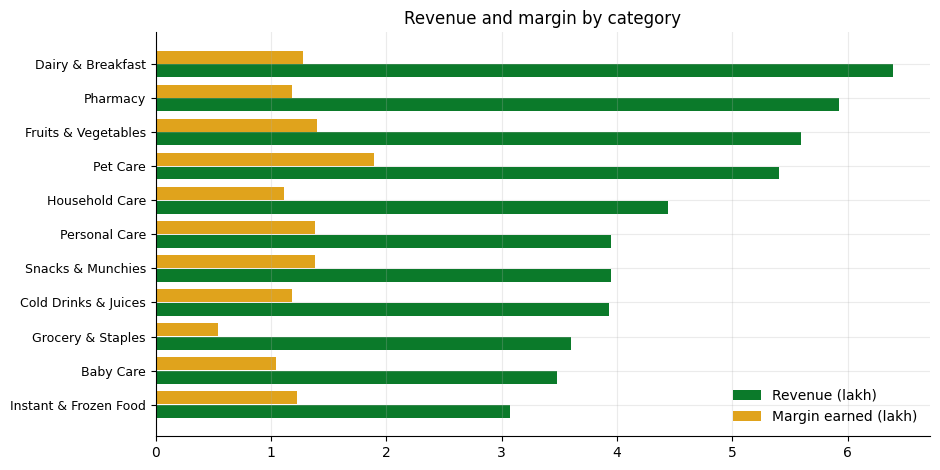

In [14]:
c = q('SELECT category, SUM(revenue) AS revenue, SUM(margin_value) AS margin FROM f_sales GROUP BY 1').sort_values('revenue')
fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(c))
ax.barh(y - .2, c.revenue/1e5, height=.38, color=GREEN, label='Revenue (lakh)')
ax.barh(y + .2, c.margin/1e5, height=.38, color=GOLD, label='Margin earned (lakh)')
ax.set_yticks(y); ax.set_yticklabels(c.category, fontsize=9); ax.legend(frameon=False)
ax.set_title('Revenue and margin by category'); plt.tight_layout(); plt.show()